In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding = 'latin1')
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# total sales and total profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print('Total Sales:', total_sales)
print('Total Profit:', total_profit)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217


In [8]:
#top-selling product category
top_selling_category = df.groupby('Category')['Sales'].sum().idxmax()
print('Top-selling product category:', top_selling_category)

Top-selling product category: Technology


In [9]:
# monthly sales trends.
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()
print('Monthly Sales Trends:')
print(monthly_sales)

Monthly Sales Trends:
Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


In [10]:
# region generates highest revenue
region_revenue = df.groupby('Region')['Sales'].sum()
highest_revenue_region = region_revenue.idxmax()
print('Region that generates highest revenue:', highest_revenue_region)

Region that generates highest revenue: West


In [11]:
# loss-making products/categories
loss_making_products = df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().idxmin()
print('Loss-making products/categories:', loss_making_products)

Loss-making products/categories: Binders


Visualization

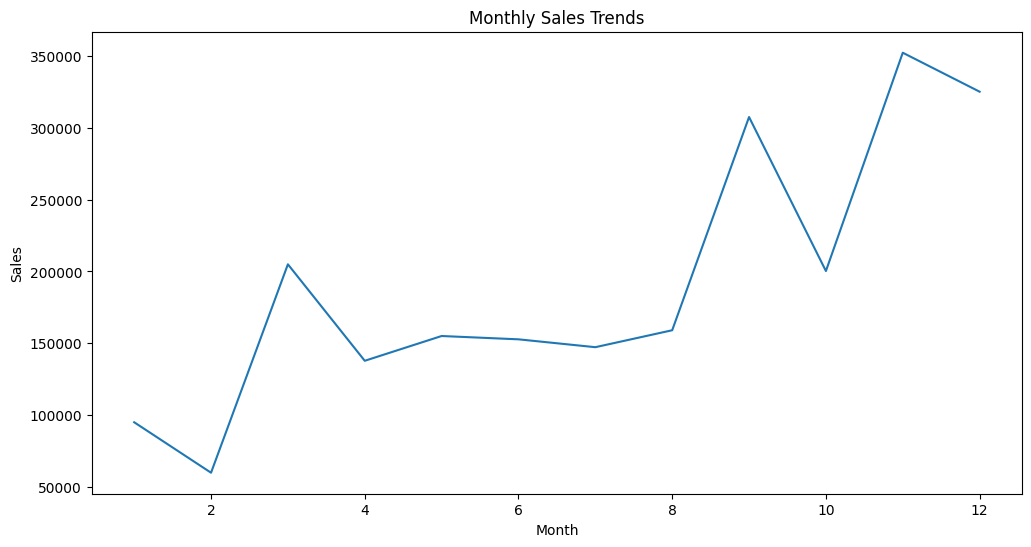

In [12]:
# Monthly sales trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Sales', data=df.groupby('Month')['Sales'].sum().reset_index())
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

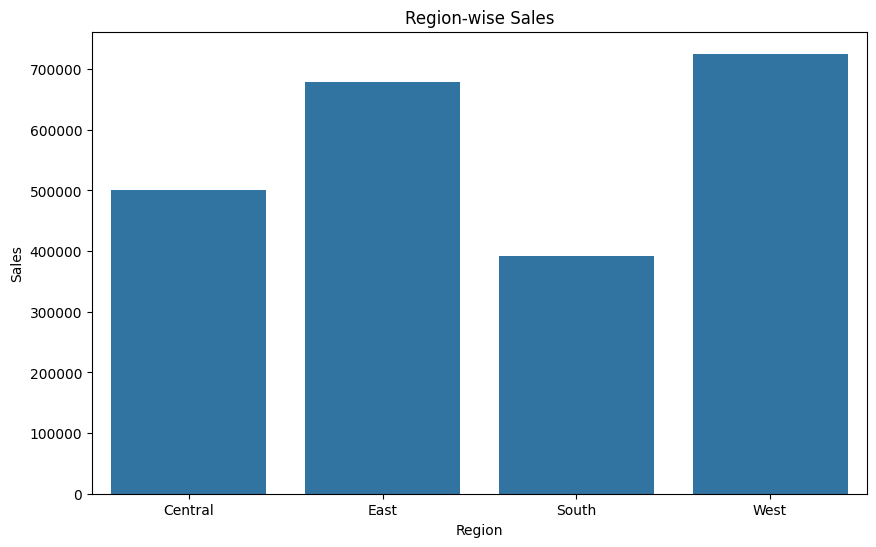

In [13]:
# Region-wise sales
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales', data=df.groupby('Region')['Sales'].sum().reset_index())
plt.title('Region-wise Sales')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

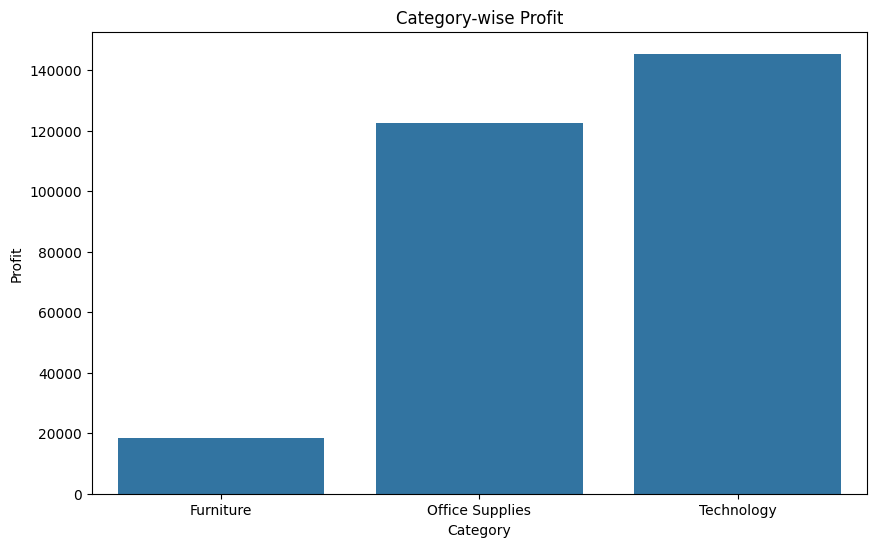

In [14]:
# category-wise profit
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Profit', data=df.groupby('Category')['Profit'].sum().reset_index())
plt.title('Category-wise Profit')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

In [15]:
print("Business Recommendations:")
print("1. Leverage Strengths in Technology Category: Consider investing more in marketing and expanding the product range within the top-selling 'Technology' category.")
print("2. Optimize Sales in the West Region: Analyze successful strategies in the 'West' region (highest revenue) and consider replicating them in other regions.")
print("3. Address Loss-Making Products (Binders): Investigate the root causes for 'Binders' being a loss-making sub-category, reviewing pricing, suppliers, or product quality.")
print("4. Strategize for Seasonal Sales Peaks and Troughs: Implement targeted marketing campaigns during peak seasons (Nov/Dec) and consider promotions to boost sales during slower months (Feb).")
print("5. Expand Product Offerings in Furniture Category: Conduct deeper analysis into customer preferences and introduce new, profitable furniture items to increase sales and profit margins.")

Business Recommendations:
1. Leverage Strengths in Technology Category: Consider investing more in marketing and expanding the product range within the top-selling 'Technology' category.
2. Optimize Sales in the West Region: Analyze successful strategies in the 'West' region (highest revenue) and consider replicating them in other regions.
3. Address Loss-Making Products (Binders): Investigate the root causes for 'Binders' being a loss-making sub-category, reviewing pricing, suppliers, or product quality.
4. Strategize for Seasonal Sales Peaks and Troughs: Implement targeted marketing campaigns during peak seasons (Nov/Dec) and consider promotions to boost sales during slower months (Feb).
5. Expand Product Offerings in Furniture Category: Conduct deeper analysis into customer preferences and introduce new, profitable furniture items to increase sales and profit margins.
